# Delivery Delay Prediction — EDA + Feature Engineering + Tuning

**Goal**: predict `delivery_delay_days` (negative = early, positive = late)  
**Data**: `gold.fct_orders` via Iceberg REST catalog (localhost:8181)  
**Stack**: XGBoost + Optuna → push best model to MLflow (localhost:5000)

Baseline script: RMSE=9.37, MAE=6.15, R²=0.143  
Problem: `estimated_delivery_days` not used, no time-based features, no seller info

## 0. Setup

In [19]:
import os, sys
sys.path.insert(0, os.path.join("..", "training"))

os.environ.setdefault("ICEBERG_REST_URI", "http://localhost:8181")

from dotenv import load_dotenv
load_dotenv(os.path.join("..", "..", ".env"))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

SEED = 42
print("Setup OK")

Setup OK


## 1. Load Data

In [20]:
from utils import load_gold_table

raw = load_gold_table("gold.fct_orders")
print(f"Shape: {raw.shape}")
raw.head(3)

Shape: (99662, 24)


,order_id,customer_id,customer_unique_id,order_status,order_date,order_month,purchased_at,approved_at,shipped_at,delivered_at,...,customer_city,order_revenue,order_freight,item_count,payment_value,payment_type,max_installments,review_score,total_weight_g,delivery_status
0,00891ba5de66f55000ee358ceea9b345,03ed7b1b35f2e55b0f4d0b9e4e07b0c3,d0cceb06b81f83e06c5cb63c3f9cb8d3,delivered,2017-05-14,2017-05,2017-05-14 17:19:43+00:00,2017-05-14 17:35:15+00:00,2017-05-15 09:03:10+00:00,2017-05-23 15:05:29+00:00,...,brasilia,133.00,16.69,1,149.69,credit_card,4.0,5.0,650.0,early
1,00c9f7d4b0e87781465e562dc109f6aa,cea80f9af87104810bd7fa9698f69d29,aed98e376f0a3685776366a2ba55e4ee,delivered,2017-05-21,2017-05,2017-05-21 19:21:32+00:00,2017-05-22 19:25:17+00:00,2017-05-24 13:28:02+00:00,2017-05-31 14:04:41+00:00,...,rio verde,59.96,60.40,4,120.36,credit_card,10.0,4.0,3600.0,early
2,00fb055886536063afa0dbee07a0944f,ab9e9b26c172c928efe04a741772958f,696b9f2a7a5565a5b79d8490514d3f3e,delivered,2017-05-24,2017-05,2017-05-24 09:04:32+00:00,2017-05-26 02:25:13+00:00,2017-05-26 10:28:12+00:00,2017-06-01 17:29:32+00:00,...,rio de janeiro,23.80,33.58,2,57.38,boleto,1.0,5.0,600.0,early


In [21]:
# Filter: only delivered orders with known delay
df = raw[
    (raw["order_status"] == "delivered") &
    raw["delivery_delay_days"].notna()
].copy()

print(f"Delivered orders: {len(df):,}  ({len(df)/len(raw)*100:.1f}% of total)")
df.dtypes

Delivered orders: 96,470  (96.8% of total)


order_id                                object
customer_id                             object
customer_unique_id                      object
order_status                            object
order_date                              object
order_month                             object
purchased_at               datetime64[us, UTC]
approved_at                datetime64[us, UTC]
shipped_at                 datetime64[us, UTC]
delivered_at               datetime64[us, UTC]
actual_delivery_days                   float64
estimated_delivery_days                  int32
delivery_delay_days                    float64
customer_state                          object
customer_city                           object
order_revenue                          float64
order_freight                          float64
item_count                               int64
payment_value                          float64
payment_type                            object
max_installments                       float64
review_score 

## 2. EDA

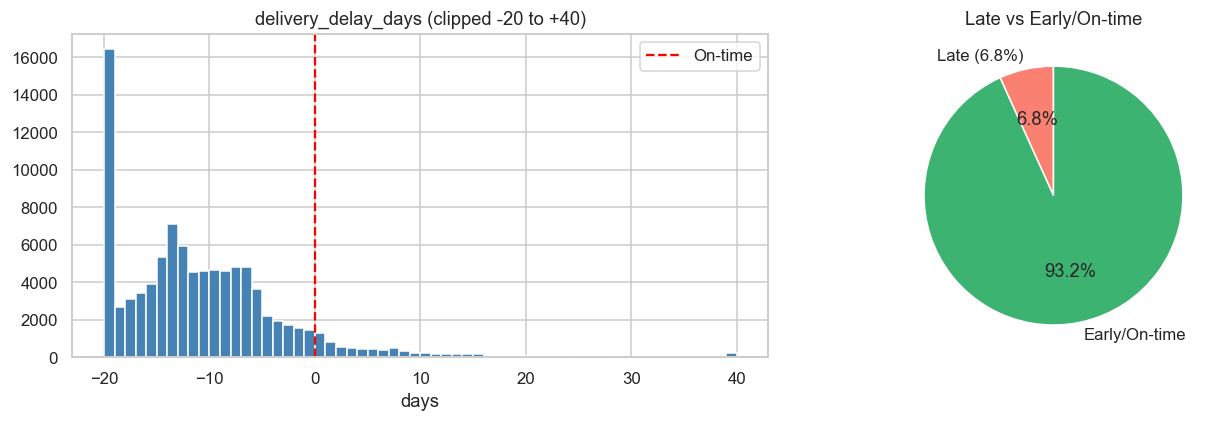

count    96470.00
mean       -11.88
std         10.18
min       -147.00
25%        -17.00
50%        -12.00
75%         -7.00
max        188.00
Name: delivery_delay_days, dtype: float64


In [22]:
# ── Target distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["delivery_delay_days"].clip(-20, 40), bins=60, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", ls="--", lw=1.5, label="On-time")
axes[0].set_title("delivery_delay_days (clipped -20 to +40)")
axes[0].set_xlabel("days")
axes[0].legend()

late_pct = (df["delivery_delay_days"] > 0).mean() * 100
axes[1].pie(
    [late_pct, 100 - late_pct],
    labels=[f"Late ({late_pct:.1f}%)", f"Early/On-time"],
    colors=["salmon", "mediumseagreen"],
    autopct="%1.1f%%", startangle=90
)
axes[1].set_title("Late vs Early/On-time")

plt.tight_layout()
plt.show()

print(df["delivery_delay_days"].describe().round(2))

In [23]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values:")
print(missing.to_string() if len(missing) else "  None")

Missing values:
review_score        646
total_weight_g       16
approved_at          14
max_installments      1
shipped_at            1


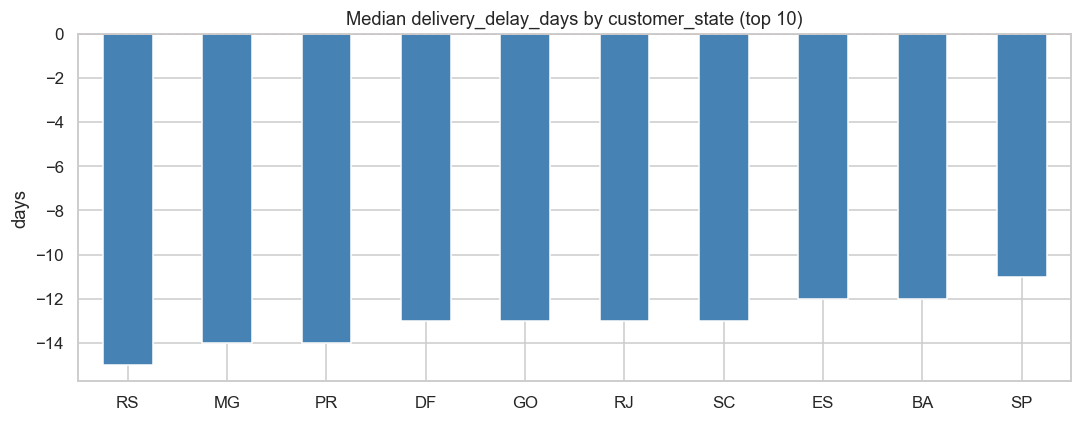

In [24]:
# ── Delay by customer_state (top 10 states) ───────────────────────────────────
top_states = df["customer_state"].value_counts().head(10).index
state_delay = (
    df[df["customer_state"].isin(top_states)]
    .groupby("customer_state")["delivery_delay_days"]
    .median()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 4))
state_delay.plot(kind="bar", ax=ax, color="steelblue")
ax.axhline(0, color="red", ls="--", lw=1)
ax.set_title("Median delivery_delay_days by customer_state (top 10)")
ax.set_ylabel("days")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

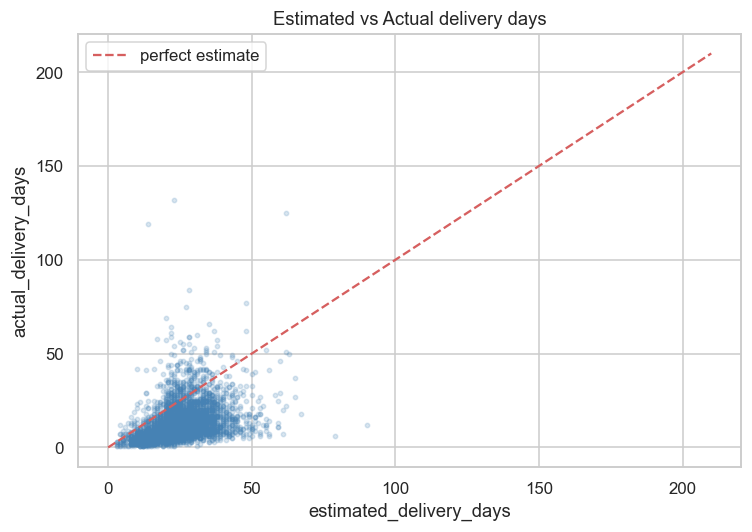

                         estimated_delivery_days  actual_delivery_days  \
estimated_delivery_days                    1.000                 0.384   
actual_delivery_days                       0.384                 1.000   
delivery_delay_days                       -0.499                 0.608   

                         delivery_delay_days  
estimated_delivery_days               -0.499  
actual_delivery_days                   0.608  
delivery_delay_days                    1.000  


In [25]:
# ── estimated_delivery_days vs actual ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
sample = df.sample(5000, random_state=SEED)
ax.scatter(sample["estimated_delivery_days"], sample["actual_delivery_days"],
           alpha=0.2, s=8, color="steelblue")
lims = [0, max(df["estimated_delivery_days"].max(), df["actual_delivery_days"].max())]
ax.plot(lims, lims, "r--", lw=1.5, label="perfect estimate")
ax.set_xlabel("estimated_delivery_days")
ax.set_ylabel("actual_delivery_days")
ax.set_title("Estimated vs Actual delivery days")
ax.legend()
plt.tight_layout()
plt.show()

corr = df[["estimated_delivery_days", "actual_delivery_days", "delivery_delay_days"]].corr()
print(corr.round(3))

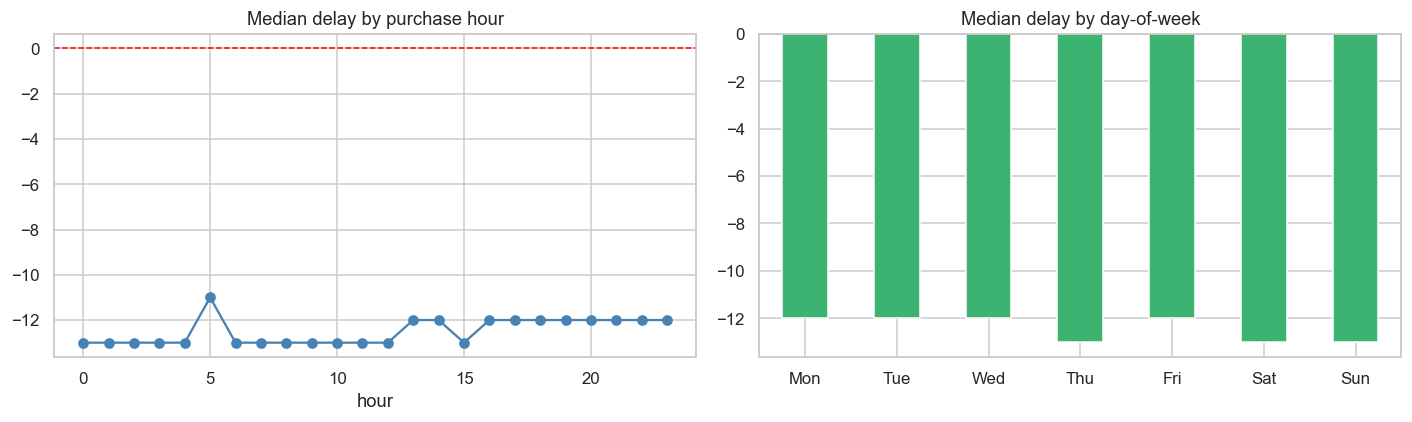

In [26]:
# ── Delay by purchase hour & day-of-week ──────────────────────────────────────
df["purchase_hour"] = df["purchased_at"].dt.hour
df["purchase_dow"]  = df["purchased_at"].dt.dayofweek  # 0=Mon

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.groupby("purchase_hour")["delivery_delay_days"].median().plot(ax=axes[0], marker="o", color="steelblue")
axes[0].axhline(0, color="red", ls="--", lw=1)
axes[0].set_title("Median delay by purchase hour")
axes[0].set_xlabel("hour")

days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
df.groupby("purchase_dow")["delivery_delay_days"].median().rename(index=dict(enumerate(days))).plot(
    kind="bar", ax=axes[1], color="mediumseagreen"
)
axes[1].axhline(0, color="red", ls="--", lw=1)
axes[1].set_title("Median delay by day-of-week")
axes[1].set_xlabel("")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

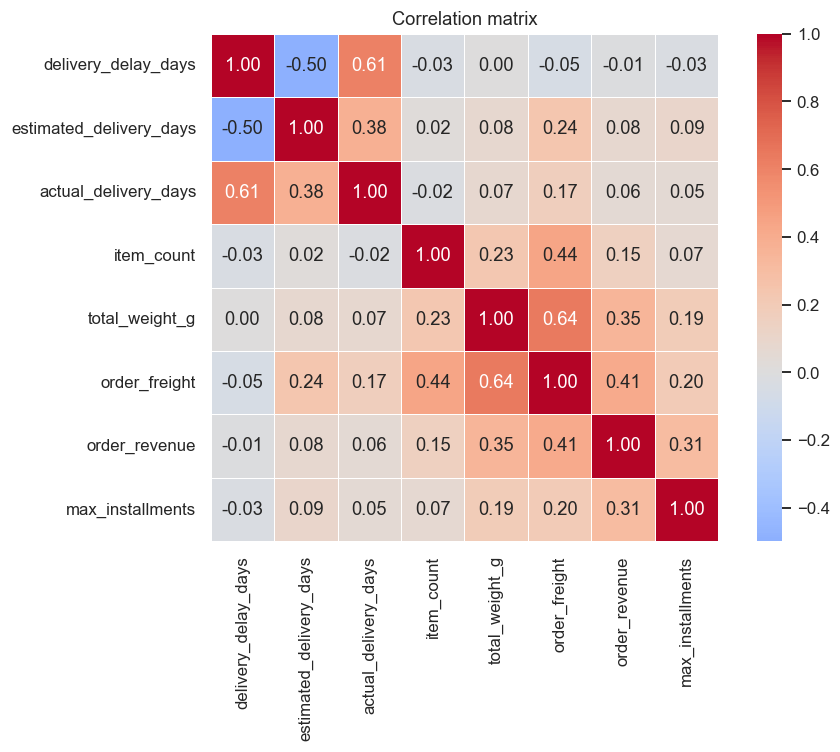

In [27]:
# ── Numeric correlations with target ─────────────────────────────────────────
num_cols_raw = [
    "delivery_delay_days", "estimated_delivery_days", "actual_delivery_days",
    "item_count", "total_weight_g", "order_freight", "order_revenue",
    "max_installments",
]
corr_mat = df[num_cols_raw].dropna().corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

## 3. Feature Engineering

Improvements over baseline script:
- Add `estimated_delivery_days` — highly correlated with actual delivery
- Time-based: `purchase_hour`, `purchase_dow`, `purchase_month`, `is_weekend`
- Process time: `approval_hours` (purchase → approved), `shipping_hours` (approved → shipped)
- Engineered: `freight_per_item`, `revenue_per_item`, `freight_ratio`

In [28]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()

    # ── Time-based ────────────────────────────────────────────────────────────
    d["purchase_hour"]  = d["purchased_at"].dt.hour
    d["purchase_dow"]   = d["purchased_at"].dt.dayofweek
    d["purchase_month"] = d["purchased_at"].dt.month
    d["is_weekend"]     = (d["purchase_dow"] >= 5).astype(int)

    # ── Processing time (hours) ───────────────────────────────────────────────
    d["approval_hours"] = (
        (d["approved_at"] - d["purchased_at"]).dt.total_seconds() / 3600
    ).clip(0, 168).fillna(24)   # cap 1 week, fill missing with 1 day

    d["shipping_hours"] = (
        (d["shipped_at"] - d["approved_at"]).dt.total_seconds() / 3600
    ).clip(0, 336).fillna(48)   # cap 2 weeks, fill missing with 2 days

    # ── Engineered numeric ────────────────────────────────────────────────────
    d["freight_per_item"] = d["order_freight"] / d["item_count"].clip(1)
    d["revenue_per_item"] = d["order_revenue"] / d["item_count"].clip(1)
    d["freight_ratio"]    = d["order_freight"] / (d["order_revenue"] + 1)
    d["total_weight_g"]   = pd.to_numeric(d["total_weight_g"], errors="coerce").fillna(0)
    d["max_installments"] = pd.to_numeric(d["max_installments"], errors="coerce").fillna(1)

    # ── Estimated delivery days (strong signal) ───────────────────────────────
    # Already numeric, just ensure no NaN
    d["estimated_delivery_days"] = pd.to_numeric(
        d["estimated_delivery_days"], errors="coerce"
    ).fillna(d["estimated_delivery_days"].median())

    # ── Categorical ──────────────────────────────────────────────────────────
    d["customer_state"] = d["customer_state"].fillna("unknown").astype(str)
    d["payment_type"]   = d["payment_type"].fillna("unknown").astype(str)

    return d


df_feat = engineer_features(df)

CAT_COLS = ["customer_state", "payment_type"]
NUM_COLS = [
    # Baseline features
    "item_count", "total_weight_g", "order_freight", "order_revenue",
    "max_installments",
    # NEW: estimated delivery
    "estimated_delivery_days",
    # NEW: time-based
    "purchase_hour", "purchase_dow", "purchase_month", "is_weekend",
    # NEW: process time
    "approval_hours", "shipping_hours",
    # NEW: engineered
    "freight_per_item", "revenue_per_item", "freight_ratio",
]
TARGET = "delivery_delay_days"

X = df_feat[CAT_COLS + NUM_COLS]
y = df_feat[TARGET].astype(float)

print(f"Features: {len(CAT_COLS + NUM_COLS)}  |  Rows: {len(X):,}")
X.head(3)

Features: 17  |  Rows: 96,470


,customer_state,payment_type,item_count,total_weight_g,order_freight,order_revenue,max_installments,estimated_delivery_days,purchase_hour,purchase_dow,purchase_month,is_weekend,approval_hours,shipping_hours,freight_per_item,revenue_per_item,freight_ratio
0,DF,credit_card,1,650.0,16.69,133.00,4.0,24,17,6,5,1,0.258889,15.465278,16.69,133.00,0.124552
1,GO,credit_card,4,3600.0,60.40,59.96,10.0,30,19,6,5,1,24.062500,42.045833,15.10,14.99,0.990814
2,RJ,boleto,2,600.0,33.58,23.80,1.0,28,9,2,5,0,41.344722,8.049722,16.79,11.90,1.354032


## 4. Baseline vs Improved — Quick Comparison

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

def make_pipeline(params: dict) -> Pipeline:
    prep = ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CAT_COLS),
        ("num", "passthrough", NUM_COLS),
    ])
    return Pipeline([("prep", prep), ("model", XGBRegressor(**params))])


def eval_model(pipeline, X_tr, y_tr, X_te, y_te, label=""):
    pipeline.fit(X_tr, y_tr)
    pred = pipeline.predict(X_te)
    rmse = float(np.sqrt(mean_squared_error(y_te, pred)))
    mae  = float(mean_absolute_error(y_te, pred))
    r2   = float(r2_score(y_te, pred))
    print(f"{label:30s}  RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.3f}")
    return rmse, mae, r2, pred


BASE_PARAMS = {
    "n_estimators": 200, "max_depth": 6, "learning_rate": 0.05,
    "subsample": 0.8, "colsample_bytree": 0.8,
    "objective": "reg:squarederror", "random_state": SEED, "n_jobs": -1,
}

# Baseline: use only the old features (replicate script)
OLD_CAT = ["customer_state", "payment_type"]
OLD_NUM = ["item_count", "total_weight_g", "order_freight",
           "order_revenue", "max_installments"]

# Add order_month_num for baseline parity
df_feat["order_month_num"] = df_feat["purchased_at"].dt.month
OLD_NUM_2 = OLD_NUM + ["order_month_num"]

prep_old = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), OLD_CAT),
    ("num", "passthrough", OLD_NUM_2),
])
pipe_old = Pipeline([("prep", prep_old), ("model", XGBRegressor(**BASE_PARAMS))])
pipe_new = make_pipeline(BASE_PARAMS)

print(f"{'Model':30s}  {'RMSE':>8}  {'MAE':>7}  {'R²':>7}")
print("-" * 60)

X_tr_old = df_feat.loc[X_train.index, OLD_CAT + OLD_NUM_2]
X_te_old = df_feat.loc[X_test.index,  OLD_CAT + OLD_NUM_2]
eval_model(pipe_old, X_tr_old, y_train, X_te_old, y_test, "Baseline (script)")

rmse_new, mae_new, r2_new, pred_new = eval_model(
    pipe_new, X_train, y_train, X_test, y_test, "Improved features"
)

Model                               RMSE      MAE       R²
------------------------------------------------------------
Baseline (script)               RMSE=9.381  MAE=6.158  R²=0.142
Improved features               RMSE=7.318  MAE=4.229  R²=0.478


## 5. Hyperparameter Tuning — Optuna

In [30]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 20),
        "gamma":             trial.suggest_float("gamma", 0, 5),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "objective":         "reg:squarederror",
        "random_state":      SEED,
        "n_jobs":            -1,
    }
    pipe = make_pipeline(params)
    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    return -scores.mean()


study = optuna.create_study(direction="minimize", study_name="delivery-delay-xgb")
study.optimize(objective, n_trials=60, show_progress_bar=True)

print(f"\nBest CV RMSE: {study.best_value:.4f}")
print("Best params:", study.best_params)

  0%|          | 0/60 [00:00<?, ?it/s]


Best CV RMSE: 7.3104
Best params: {'n_estimators': 573, 'max_depth': 9, 'learning_rate': 0.016730918320961078, 'subsample': 0.6981353928609205, 'colsample_bytree': 0.835130084047527, 'min_child_weight': 19, 'gamma': 0.4460385697093827, 'reg_alpha': 0.0006340847702573237, 'reg_lambda': 0.0002528819555215837}


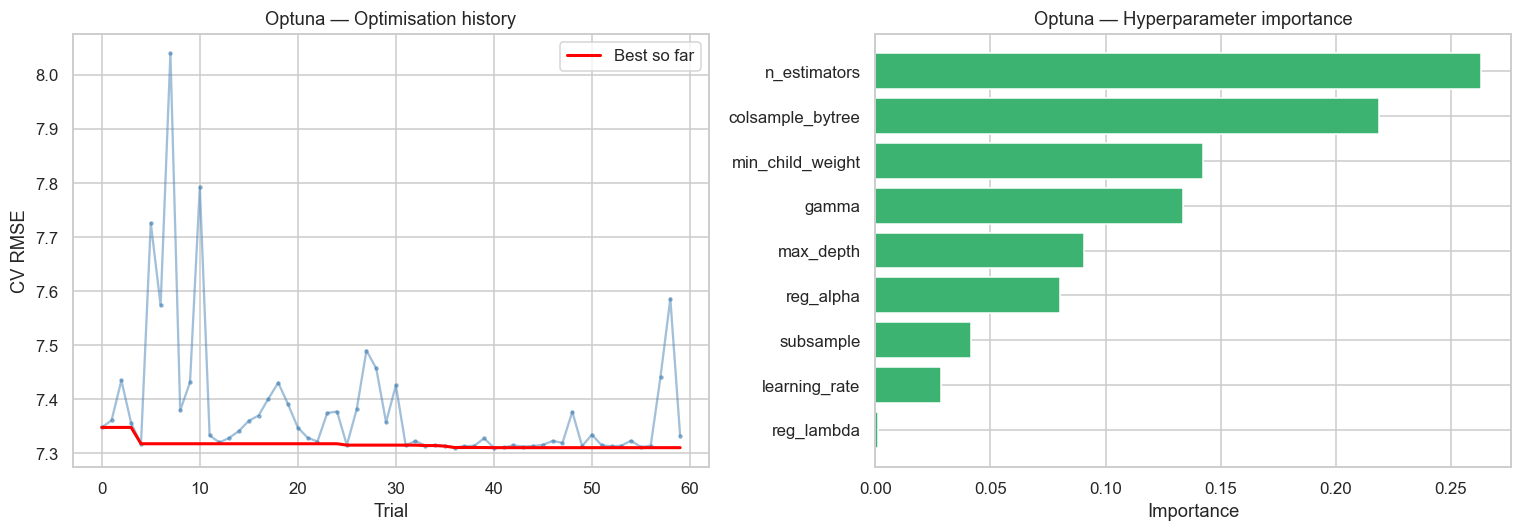

In [31]:
# ── Optuna visualisations ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimisation history
trials_df = study.trials_dataframe()
axes[0].plot(trials_df["number"], trials_df["value"], alpha=0.5, color="steelblue", marker=".", ms=4)
axes[0].plot(trials_df["number"],
             trials_df["value"].cummin(),
             color="red", lw=2, label="Best so far")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("CV RMSE")
axes[0].set_title("Optuna — Optimisation history")
axes[0].legend()

# Param importances (manual)
importances = optuna.importance.get_param_importances(study)
names  = list(importances.keys())
values = list(importances.values())
axes[1].barh(names[::-1], values[::-1], color="mediumseagreen")
axes[1].set_title("Optuna — Hyperparameter importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 6. Train Best Model & Evaluate

In [32]:
best_params = {
    **study.best_params,
    "objective": "reg:squarederror",
    "random_state": SEED,
    "n_jobs": -1,
}

best_pipe = make_pipeline(best_params)
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

rmse_best = float(np.sqrt(mean_squared_error(y_test, y_pred)))
mae_best  = float(mean_absolute_error(y_test, y_pred))
r2_best   = float(r2_score(y_test, y_pred))

print(f"Best model — RMSE={rmse_best:.3f}  MAE={mae_best:.3f}  R²={r2_best:.3f}")
print(f"Baseline   — RMSE=9.374           MAE=6.154           R²=0.143")

Best model — RMSE=7.290  MAE=4.193  R²=0.482
Baseline   — RMSE=9.374           MAE=6.154           R²=0.143


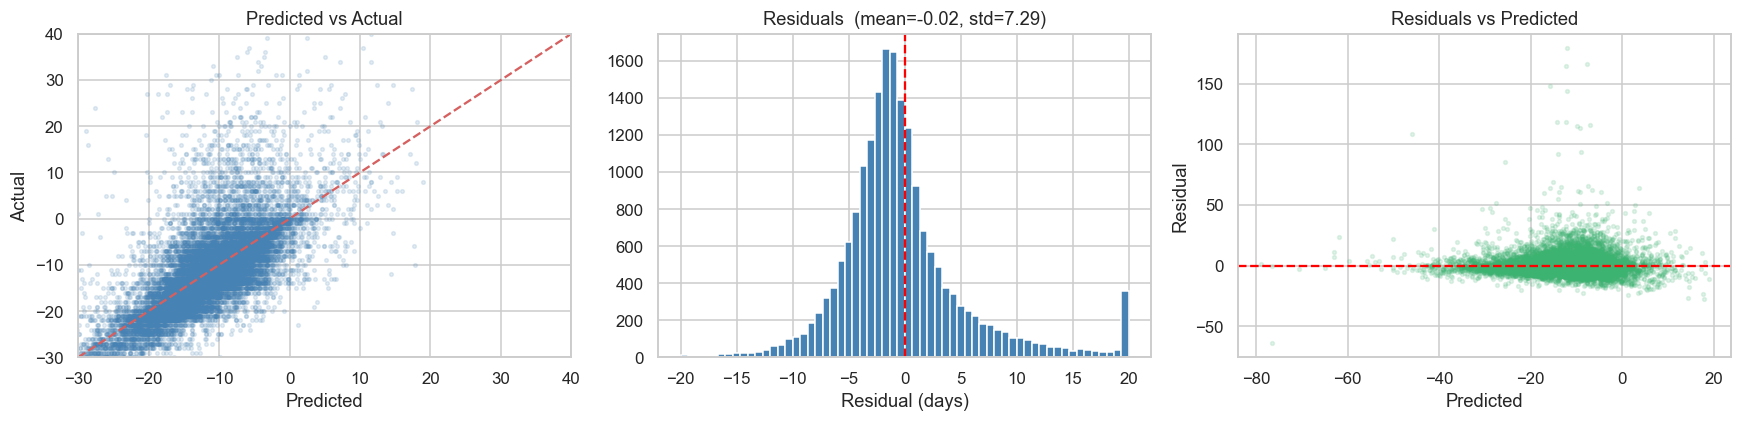

In [33]:
# ── Residuals analysis ────────────────────────────────────────────────────────
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Predicted vs Actual
axes[0].scatter(y_pred, y_test.values, alpha=0.15, s=6, color="steelblue")
lim = (-30, 40)
axes[0].plot(lim, lim, "r--", lw=1.5)
axes[0].set_xlim(*lim)
axes[0].set_ylim(*lim)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Predicted vs Actual")

# Residuals distribution
axes[1].hist(residuals.clip(-20, 20), bins=60, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", ls="--", lw=1.5)
axes[1].set_xlabel("Residual (days)")
axes[1].set_title(f"Residuals  (mean={residuals.mean():.2f}, std={residuals.std():.2f})")

# Residuals vs Predicted
axes[2].scatter(y_pred, residuals, alpha=0.15, s=6, color="mediumseagreen")
axes[2].axhline(0, color="red", ls="--", lw=1.5)
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Residual")
axes[2].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.show()

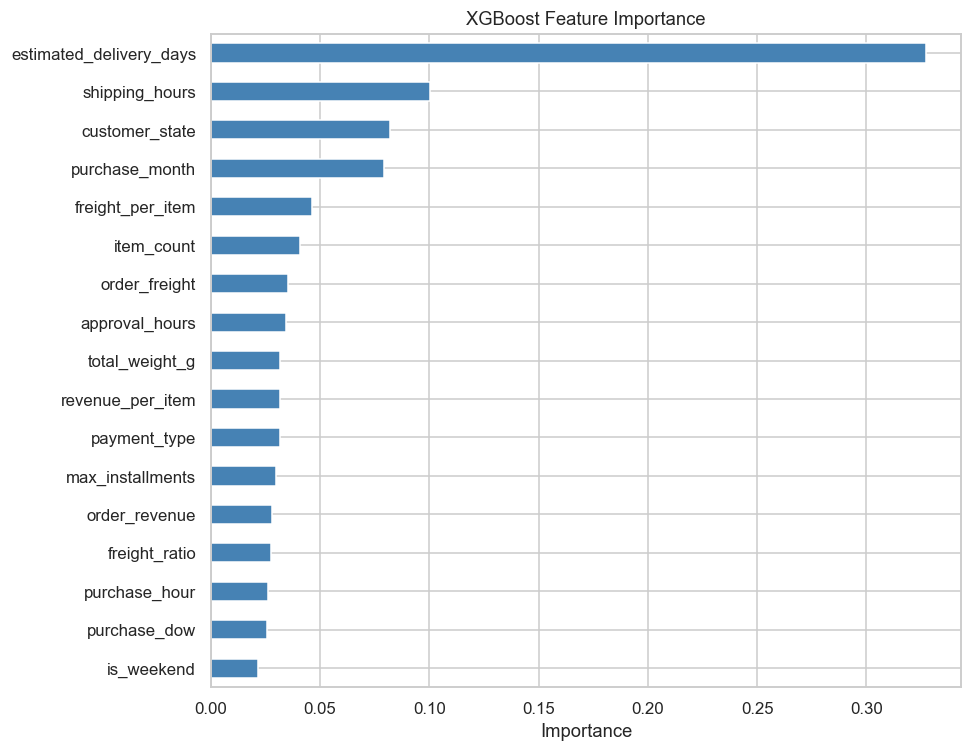

estimated_delivery_days    0.327157
shipping_hours             0.100430
customer_state             0.081989
purchase_month             0.079315
freight_per_item           0.046513
item_count                 0.041055
order_freight              0.035353
approval_hours             0.034357
total_weight_g             0.031718
revenue_per_item           0.031645
payment_type               0.031588
max_installments           0.029675
order_revenue              0.028077
freight_ratio              0.027641
purchase_hour              0.026218
purchase_dow               0.025817
is_weekend                 0.021453


In [34]:
# ── Feature importance ────────────────────────────────────────────────────────
xgb_model = best_pipe.named_steps["model"]
feat_names = CAT_COLS + NUM_COLS
fi = pd.Series(
    xgb_model.feature_importances_,
    index=feat_names
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
fi.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("XGBoost Feature Importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print(fi.sort_values(ascending=False).to_string())

In [35]:
# ── Error breakdown: where does the model fail? ───────────────────────────────
eval_df = X_test.copy()
eval_df["actual"]    = y_test.values
eval_df["predicted"] = y_pred
eval_df["error"]     = residuals
eval_df["abs_error"] = np.abs(residuals)

print("Top 10 worst predictions (highest abs error):")
eval_df.nlargest(10, "abs_error")[["customer_state", "estimated_delivery_days",
                                    "actual", "predicted", "error"]].round(1)

Top 10 worst predictions (highest abs error):


,customer_state,estimated_delivery_days,actual,predicted,error
80187,SP,23,167.0,-12.1,179.1
79545,SE,29,159.0,-7.6,166.6
98384,GO,29,152.0,-12.3,164.3
80186,RR,40,132.0,-15.8,147.8
81660,CE,36,132.0,-12.1,144.1
66483,ES,37,106.0,-12.2,118.2
56865,BA,34,104.0,-14.2,118.2
26112,RJ,23,109.0,-7.0,116.0
94181,SP,14,105.0,-9.9,114.9
39547,RJ,27,104.0,-9.2,113.2


## 7. Log Best Model to MLflow

Only run this cell when you're satisfied with the metrics.

In [ ]:
import mlflow
import mlflow.sklearn
import tempfile
from utils import setup_mlflow

EXPERIMENT = "delivery-delay-prediction"
MODEL_NAME  = "delivery-delay-xgb"

os.environ.setdefault("MLFLOW_TRACKING_URI", "http://localhost:5000")
setup_mlflow()
mlflow.set_experiment(EXPERIMENT)

with mlflow.start_run(run_name="optuna-tuned-v1") as run:
    mlflow.log_params({
        **best_params,
        "train_rows":    len(X_train),
        "test_rows":     len(X_test),
        "n_features":    len(feat_names),
        "features":      ",".join(feat_names),
        "optuna_trials": len(study.trials),
        "cv_rmse":       round(study.best_value, 4),
    })

    mlflow.log_metrics({"rmse": rmse_best, "mae": mae_best, "r2": r2_best})

    fi_path = os.path.join(tempfile.gettempdir(), "delivery_fi_tuned.csv")
    fi.sort_values(ascending=False).to_csv(fi_path, header=["importance"])
    mlflow.log_artifact(fi_path)

    mlflow.sklearn.log_model(
        best_pipe, "model",
        registered_model_name=MODEL_NAME,
        input_example=X_test.head(5),
    )

    print(f"Run ID   : {run.info.run_id}")
    print(f"RMSE     : {rmse_best:.4f}  (baseline 9.374)")
    print(f"MAE      : {mae_best:.4f}  (baseline 6.154)")
    print(f"R²       : {r2_best:.4f}  (baseline 0.143)")
    print(f"MLflow UI: http://localhost:5000")